# 1.1 Interactive Environments in the Modern AI/ML Stack


Interactive code-writing environments like Jupyter Notebook are beloved by data scientists and ML researchers because they combine software code, computational output, and explanatory text in a single document.

In this notebook, we'll train a classifier on a 2D dataset, visualize what it learned, and then **change things and see what happens**. This is the core loop of AI/ML work.

Along the way, we'll also get to know **TabICL**, a foundation model for tabular classification that works out of the box with zero hyperparameter tuning.

## Setup

Run the next cell once before the rest of the notebook. If `tabicl` is missing, uncomment the `%pip` line first.

In [9]:
# Uncomment if needed:
%pip install tabicl scikit-learn matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.model_selection import train_test_split
from tabicl import TabICLClassifier


  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pyyaml-6.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.4 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)

/Users/parulpandey/Desktop/Marimo Workshop/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Look at the data

Before we do any modelling, we need to **see** our data. This is always the first step.

We'll generate a classic "two moons" dataset — two interleaving half-circles that are easy to visualise but non-trivial to classify.

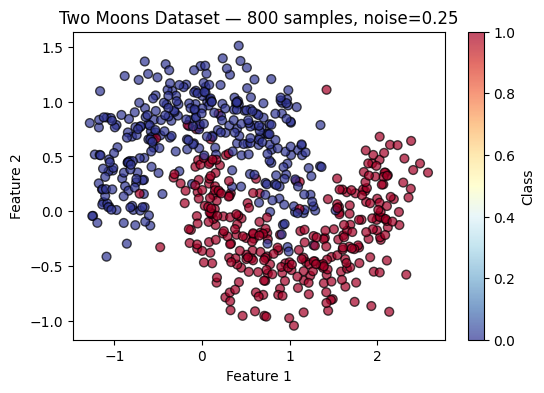

Training samples: 640, Test samples: 160


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons, make_circles
from sklearn.metrics import roc_auc_score, accuracy_score

# Generate a two-moon dataset
NOISE = 0.25
N_SAMPLES = 800

X, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Let's see what we're working with
fig, ax = plt.subplots(figsize=(6, 4))
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
                     cmap="RdYlBu_r", edgecolors="k", s=40, alpha=0.7)
ax.set(xlabel="Feature 1", ylabel="Feature 2")
ax.set_title(f"Two Moons Dataset — {N_SAMPLES} samples, noise={NOISE}")
plt.colorbar(scatter, ax=ax, label="Class")
plt.show()

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")

## Step 2: Classify with TabICL

**TabICL** is a foundation model for tabular data — think of it as a pre-trained model that already understands tabular classification patterns, so it works well out of the box without any hyperparameter tuning.

Let's fit it and see what it predicts.

In [11]:
from tabicl import TabICLClassifier

# Fit TabICL — no hyperparameters to tune
model = TabICLClassifier()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# How did it do?
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba[:, 1])

print(f"Accuracy:  {acc:.3f}")
print(f"ROC AUC:   {roc:.3f}")

INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.

Accuracy:  0.944
ROC AUC:   0.994


## Step 3: Visualize what the model learned

Numbers are useful, but **seeing** the model's decision boundary tells us so much more. 

We'll create a grid across the entire feature space and ask TabICL: "How confident are you about each point?" The resulting probability map shows us exactly where the model is certain and where it's unsure.

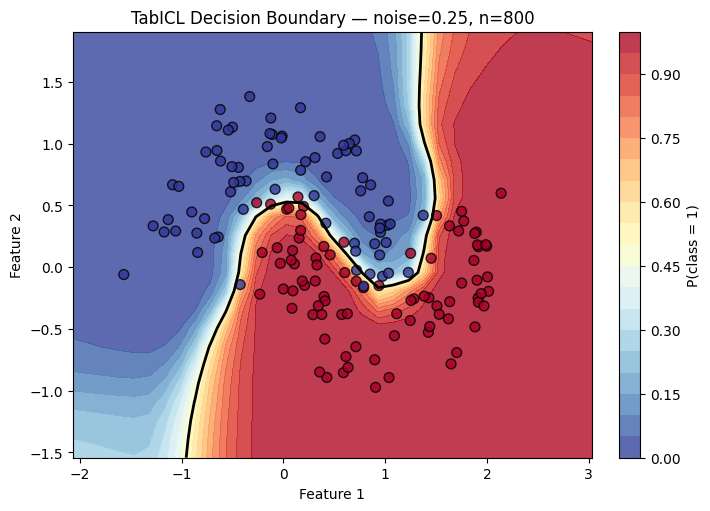

In [12]:
def plot_decision_boundary(model, X, y, X_test, y_test, title=None):
    """Plot the decision boundary with probability shading."""
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    
    # Create a mesh covering the feature space
    h = 0.15
    offset = 0.5
    x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
    y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h), 
        np.arange(y_min, y_max, h)
    )
    
    # Predict probability at every point in the mesh
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
    Z = Z.reshape(xx.shape)
    
    # Plot probability surface
    contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.8)
    ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    
    # Overlay test points
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdYlBu_r",
               edgecolors="k", s=50, alpha=0.8)
    
    ax.set(xlabel="Feature 1", ylabel="Feature 2")
    if title:
        ax.set_title(title)
    plt.colorbar(contour, ax=ax, label="P(class = 1)")
    plt.show()

# Plot it
plot_decision_boundary(
    model, X, y, X_test, y_test,
    title=f"TabICL Decision Boundary — noise={NOISE}, n={N_SAMPLES}"
)

### How to interpret the decision boundary

The colored background shows what the model would predict for any point in the feature space.

- Warm and cool regions correspond to the two predicted classes.
- The boundary is the line where the model switches from one class to the other.
- A clean boundary usually means the classes are easier to separate.
- A messy or curved boundary can suggest noise, overlap, or a more complex pattern.
- Points close to the boundary are the most uncertain because small changes could flip the prediction.


## Step 4: What happens when we change the noise?

This is where interactive environments really shine. Instead of just reading about how noise affects a classifier, we can **change it and immediately see the result**.

Let's crank up the noise and see what happens to the decision boundary.

> **Try it yourself:** Change `NOISE` to different values like `0.15`, `0.35`, `0.50` and re-run the cells below.

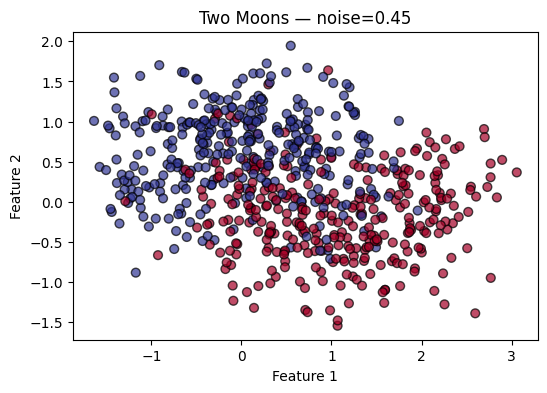

In [13]:
# --- CHANGE THIS VALUE AND RE-RUN ---
NOISE = 0.45

# Regenerate data with new noise level
X, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Quick look at the noisier data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, 
           cmap="RdYlBu_r", edgecolors="k", s=40, alpha=0.7)
ax.set(xlabel="Feature 1", ylabel="Feature 2")
ax.set_title(f"Two Moons — noise={NOISE}")
plt.show()

Accuracy:  0.800
ROC AUC:   0.905


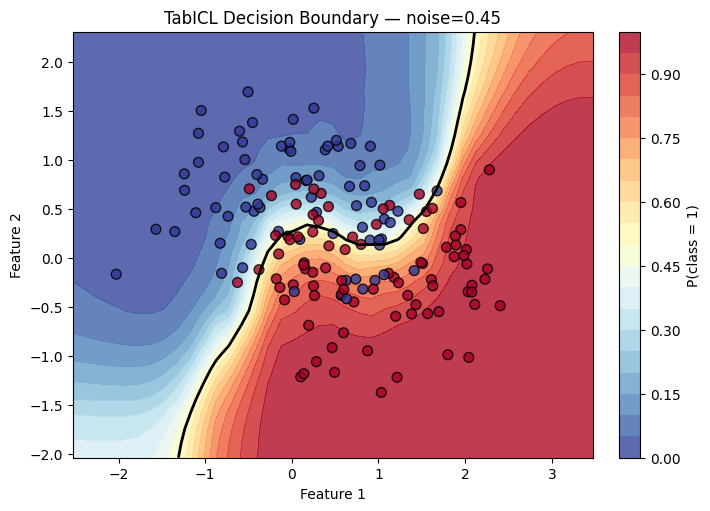

In [14]:
# Re-fit TabICL on the noisier data
model_noisy = TabICLClassifier()
model_noisy.fit(X_train, y_train)

y_pred = model_noisy.predict(X_test)
y_proba = model_noisy.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_proba[:, 1])
print(f"Accuracy:  {acc:.3f}")
print(f"ROC AUC:   {roc:.3f}")

# Visualize — notice how the boundary has changed
plot_decision_boundary(
    model_noisy, X, y, X_test, y_test,
    title=f"TabICL Decision Boundary — noise={NOISE}"
)

### What do we observe?

With more noise, the decision boundary becomes **less sharp** i.e. the model is less confident, and the transition region (where probability is close to 0.5) is wider. This is exactly what we'd want: the model expresses more uncertainty when the data is genuinely harder to classify.

 We **changed something and saw the result**. That's the power of interactive environments.

## Step 5: What about a completely different dataset?

Let's push further. Instead of two moons, what if our data has a completely different shape? Let's try **concentric circles** — one class inside the other.

This tests whether TabICL can handle fundamentally different geometric structures without us changing any model settings.

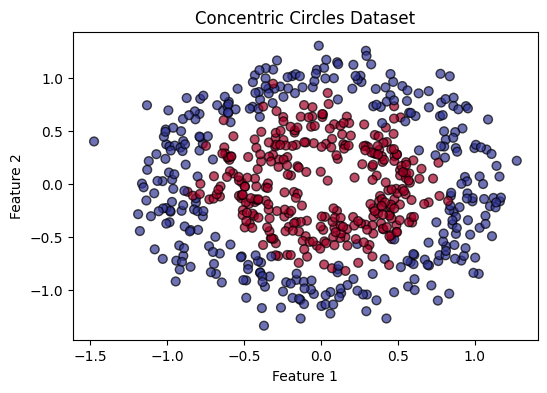

In [15]:
# Switch to a circles dataset
X_circles, y_circles = make_circles(
    n_samples=N_SAMPLES, noise=0.15, factor=0.5, random_state=0
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=0
)

# See the new shape
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X_train_c[:, 0], X_train_c[:, 1], c=y_train_c, 
           cmap="RdYlBu_r", edgecolors="k", s=40, alpha=0.7)
ax.set(xlabel="Feature 1", ylabel="Feature 2")
ax.set_title("Concentric Circles Dataset")
plt.show()

Accuracy:  0.950
ROC AUC:   0.992


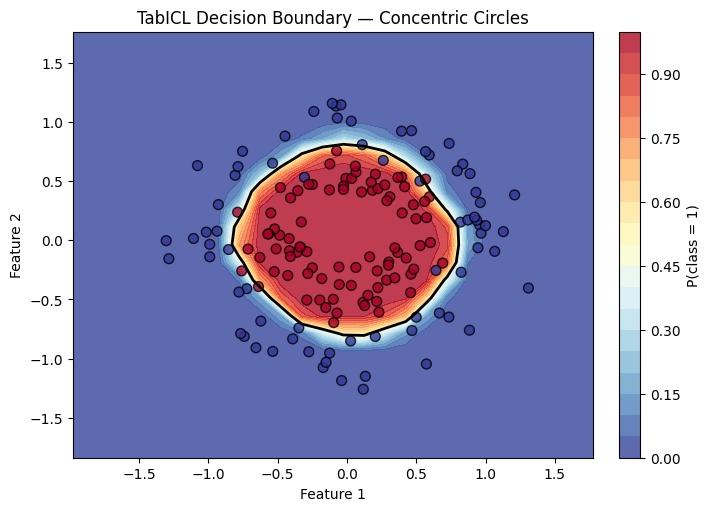

In [16]:
# Fit TabICL on circles — exact same code, different data
model_circles = TabICLClassifier()
model_circles.fit(X_train_c, y_train_c)

y_pred_c = model_circles.predict(X_test_c)
y_proba_c = model_circles.predict_proba(X_test_c)

acc = accuracy_score(y_test_c, y_pred_c)
roc = roc_auc_score(y_test_c, y_proba_c[:, 1])
print(f"Accuracy:  {acc:.3f}")
print(f"ROC AUC:   {roc:.3f}")

# Visualize
plot_decision_boundary(
    model_circles, X_circles, y_circles, X_test_c, y_test_c,
    title="TabICL Decision Boundary — Concentric Circles"
)


This is the core loop of AI/ML work:

1. **Write** a few lines of code
2. **See** the result immediately  
3. **Change** something — the data, a parameter, the model
4. **See** how the result changes

This loop runs hundreds of times a day in real ML work. The faster it runs, the faster you learn. Interactive environments like this notebook make that loop as tight as possible.

## Step 6: How does TabICL compare to a traditional classifier?

One more experiment. Let's compare TabICL side-by-side with a standard Random Forest on the same data. This is the kind of quick comparison that interactive environments make effortless.

In [17]:
from sklearn.ensemble import RandomForestClassifier

# Go back to moons with moderate noise
NOISE = 0.30
X, y = make_moons(n_samples=N_SAMPLES, noise=NOISE, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Fit both models
tabicl_model = TabICLClassifier()
tabicl_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=0)
rf_model.fit(X_train, y_train)

# Compare metrics
for name, m in [("TabICL", tabicl_model), ("Random Forest", rf_model)]:
    y_pred = m.predict(X_test)
    y_proba = m.predict_proba(X_test)
    print(f"{name:15s}  Accuracy: {accuracy_score(y_test, y_pred):.3f}  "
          f"ROC AUC: {roc_auc_score(y_test, y_proba[:, 1]):.3f}")

TabICL           Accuracy: 0.906  ROC AUC: 0.977
Random Forest    Accuracy: 0.887  ROC AUC: 0.958


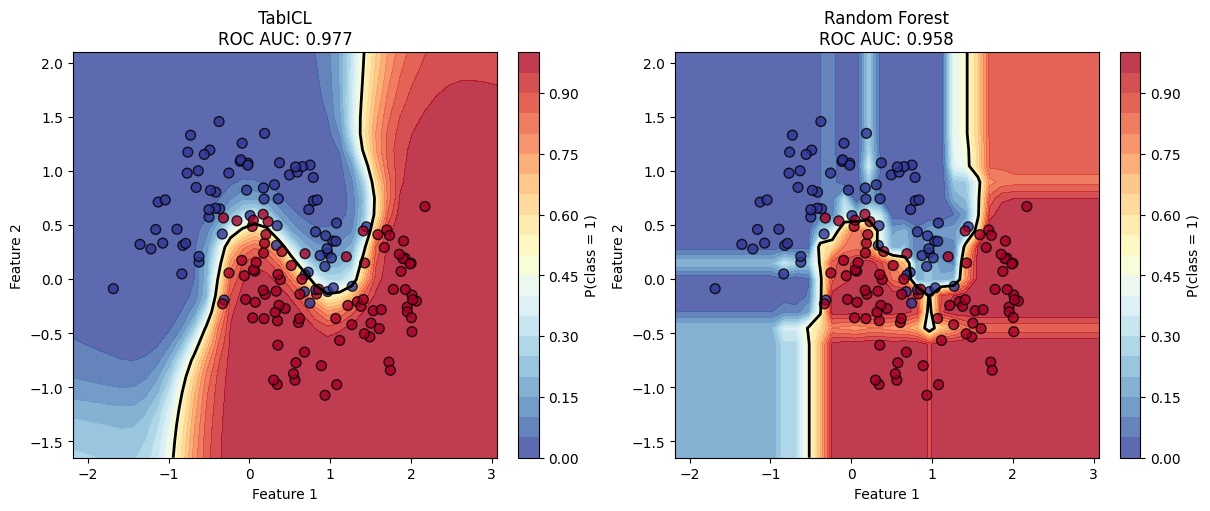

In [18]:
def plot_comparison(models, names, X, y, X_test, y_test):
    """Plot decision boundaries side by side."""
    fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 5), 
                              constrained_layout=True)
    if len(models) == 1:
        axes = [axes]
    
    h = 0.15
    offset = 0.5
    x_min, x_max = X[:, 0].min() - offset, X[:, 0].max() + offset
    y_min, y_max = X[:, 1].min() - offset, X[:, 1].max() + offset
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h), 
        np.arange(y_min, y_max, h)
    )
    
    for ax, model, name in zip(axes, models, names):
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
        Z = Z.reshape(xx.shape)
        
        contour = ax.contourf(xx, yy, Z, levels=20, cmap="RdYlBu_r", alpha=0.8)
        ax.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
        ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="RdYlBu_r",
                   edgecolors="k", s=50, alpha=0.8)
        
        y_proba = model.predict_proba(X_test)
        roc = roc_auc_score(y_test, y_proba[:, 1])
        ax.set_title(f"{name}\nROC AUC: {roc:.3f}")
        ax.set(xlabel="Feature 1", ylabel="Feature 2")
        plt.colorbar(contour, ax=ax, label="P(class = 1)")
    
    plt.show()

# Side-by-side comparison
plot_comparison(
    [tabicl_model, rf_model],
    ["TabICL", "Random Forest"],
    X, y, X_test, y_test
)

### Notice the difference

Look at the decision boundaries. The Random Forest boundary is **jagged and blocky** — that's because decision trees split the space into axis-aligned rectangles. TabICL's boundary is **smoother** and arguably more natural for this curved dataset.
